# 29 April 2026
- checking full galaxy sample of CVs
- converting to blip readable format

In [1]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'  # LSS to avoid OOM errors when using jax in this script
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import legwork as lw
import astropy.coordinates as cc
import astropy.units as u
import healpy as hp
import sys
sys.path.append('../scripts/')
import paths

In [ ]:
def convert_popsynth_to_blipreadable(input_loc, output_loc):
    """ Converts population file to blip readable format with columns f, h, lat, long.

    Parameters
    ----------
    input_loc : str
        Location of the input file containing the population synthesis data.
    output_name : str
        Name of the output file to save the converted data in blip readable format.
    """
    file = input_loc
    binaries = pd.read_csv(file)
    blip_columns = ['f','h','lat','long']
    xG, yG, zG = binaries[' x_galcent[kpc]'].to_numpy(), binaries[' y_galcent[kpc]'].to_numpy(), binaries[' z_galcent[kpc]'].to_numpy()
    ## convert to distances and lat/long ecliptic coords
    gc = cc.SkyCoord(x=xG*u.kpc,y=yG*u.kpc,z=zG*u.kpc, frame='galactocentric')
    SSBc = gc.transform_to(cc.BarycentricMeanEcliptic)

    ## get latitude, longitude
    lat = SSBc.lat.to(u.rad).value
    long = SSBc.lon.to(u.rad).value

    ## making sure we've handled our coordinate transforms correctly
    dist = SSBc.distance.to(u.kpc)
    mc = lw.utils.chirp_mass(binaries['# m1[Msun]'],binaries[' m2[Msun]']).to_numpy()*u.Msun
    fs = binaries[' f_gw[Hz]'].to_numpy()
    f_orb = fs*u.Hz/2
    ## assuming circular binaries
    ecc = np.zeros(len(f_orb))

    hs = lw.strain.h_0_n(mc,f_orb,ecc,2,dist)

    blip_df = pd.DataFrame(data=np.vstack((fs,hs.flatten(),lat,long)).T,columns=blip_columns)

    blip_df.to_csv(output_loc, index=False,sep=' ',header=False)


In [2]:
cvgxyfile = paths.lssdata / 'dat_fullgxy_rs42_final.txt'
cvgxy = pd.read_csv(cvgxyfile)
print(cvgxy.columns)


Index(['# m1[Msun]', ' m2[Msun]', ' f_gw[Hz]', ' inclination[rad]',
       ' x_galcent[kpc]', ' y_galcent[kpc]', ' z_galcent[kpc]',
       ' Scar_reassigned', ' Pala_reassigned', ' dist_from_sun[kpc]'],
      dtype='object')


In [3]:
cvgxy

,# m1[Msun],m2[Msun],f_gw[Hz],inclination[rad],x_galcent[kpc],y_galcent[kpc],z_galcent[kpc],Scar_reassigned,Pala_reassigned,dist_from_sun[kpc]
0,0.700548,0.821742,0.000077,1.370129,3.012746,-7.636290,0.425292,0.0,0.0,9.196793
1,0.700910,0.089096,0.000369,1.146334,-1.995981,-1.512412,-1.443056,0.0,0.0,10.334593
2,0.698234,0.108100,0.000333,1.209398,8.366633,-13.318012,1.254375,0.0,0.0,13.377256
3,0.699642,0.112340,0.000330,0.761463,-2.180671,-9.321401,0.961928,0.0,0.0,13.925489
4,0.699784,0.109918,0.000334,1.329256,-1.870042,4.011498,0.978920,0.0,0.0,10.809764
...,...,...,...,...,...,...,...,...,...,...
3908559,0.698753,0.083772,0.000378,1.386895,-1.568857,2.991821,-0.459733,0.0,0.0,10.153552
3908560,0.699861,0.146772,0.000284,0.475929,5.652759,-1.465680,0.797379,0.0,0.0,2.974634
3908561,0.699762,0.048480,0.000392,0.393419,-9.689314,-6.462087,3.323855,0.0,0.0,19.233087
3908562,0.700860,0.337479,0.000137,1.097728,-0.578329,9.414983,0.702464,0.0,0.0,12.837535


In [5]:
input_name = 'dat_fullgxy_rs42_final.txt'
output_name = input_name.split('.')[0]+'_blip.txt'
convert_popsynth_to_blipreadable(input_name, output_name)

(array([ 3691.,  3893.,  3898.,  4034.,  4079.,  4256.,  4292.,  4479.,
         4505.,  4779.,  4722.,  4818.,  4893.,  5026.,  5032.,  5091.,
         5223.,  5387.,  5427.,  5389.,  5443.,  5602.,  5569.,  5742.,
         5857.,  5988.,  5963.,  6025.,  5998.,  6139.,  6114.,  6191.,
         6318.,  6303.,  6513.,  6393.,  6470.,  6511.,  6571.,  6583.,
         6667.,  6926.,  6784.,  6794.,  7011.,  6942.,  6992.,  7065.,
         7232.,  7086.,  7321.,  7317.,  7324.,  7363.,  7467.,  7389.,
         7501.,  7401.,  7575.,  7677.,  7697.,  7789.,  7847.,  7786.,
         7854.,  8065.,  7991.,  7862.,  8245.,  8118.,  8063.,  8361.,
         8321.,  8590.,  8655.,  8555.,  8855.,  9113.,  9121.,  9374.,
         9323.,  9467.,  9780., 10000., 10246., 10664., 10691., 11112.,
        12050., 13410., 15836.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0., 

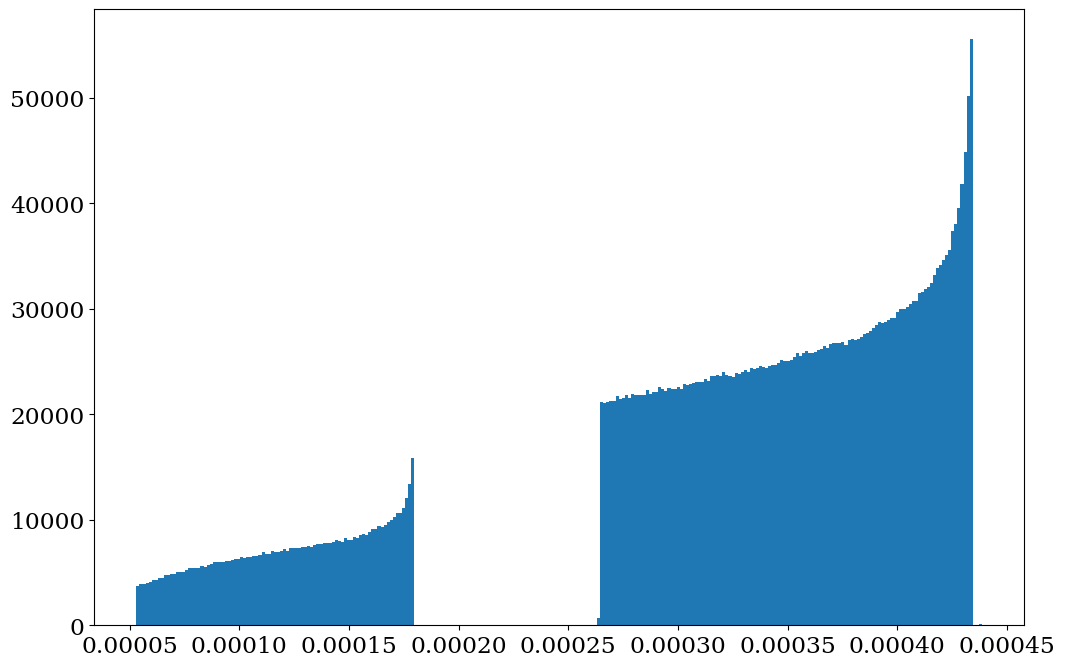

In [8]:
plt.hist(cvgxy[' f_gw[Hz]'], bins=277)

In [7]:
c_galcent = cc.SkyCoord(x=cvgxy[' x_galcent[kpc]'].values*u.kpc,y=cvgxy[' y_galcent[kpc]'].values*u.kpc,z=cvgxy[' z_galcent[kpc]'].values*u.kpc, frame='galactocentric', representation_type='cartesian')
c_ecl = c_galcent.transform_to(cc.BarycentricMeanEcliptic)
## get latitude, longitude
lat = c_ecl.lat.to(u.rad).value
long = c_ecl.lon.to(u.rad).value

<Figure size 1200x800 with 0 Axes>

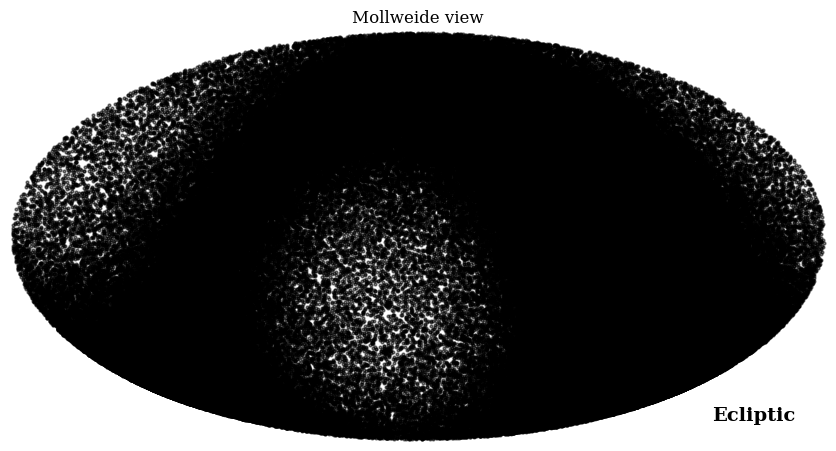

In [8]:
## check
plt.figure()
hp.mollview(coord='E')
hp.projscatter(long*u.rad.to(u.deg),lat*u.rad.to(u.deg),lonlat=True,color='k',alpha=0.5,s=4)
plt.show()

In [15]:
dwdthiele = pd.read_csv('/home/levis/lisa_projects/blip_CVs/datasets/dwd_datasets/thiele_fiducial_thin_mcmillan_galaxy.txt', delim_whitespace=True, names=['f','h','lat','long'])

/tmp/ipykernel_310461/946873003.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dwdthiele = pd.read_csv('/home/levis/lisa_projects/blip_CVs/datasets/dwd_datasets/thiele_fiducial_thin_mcmillan_galaxy.txt', delim_whitespace=True, names=['f','h','lat','long'])


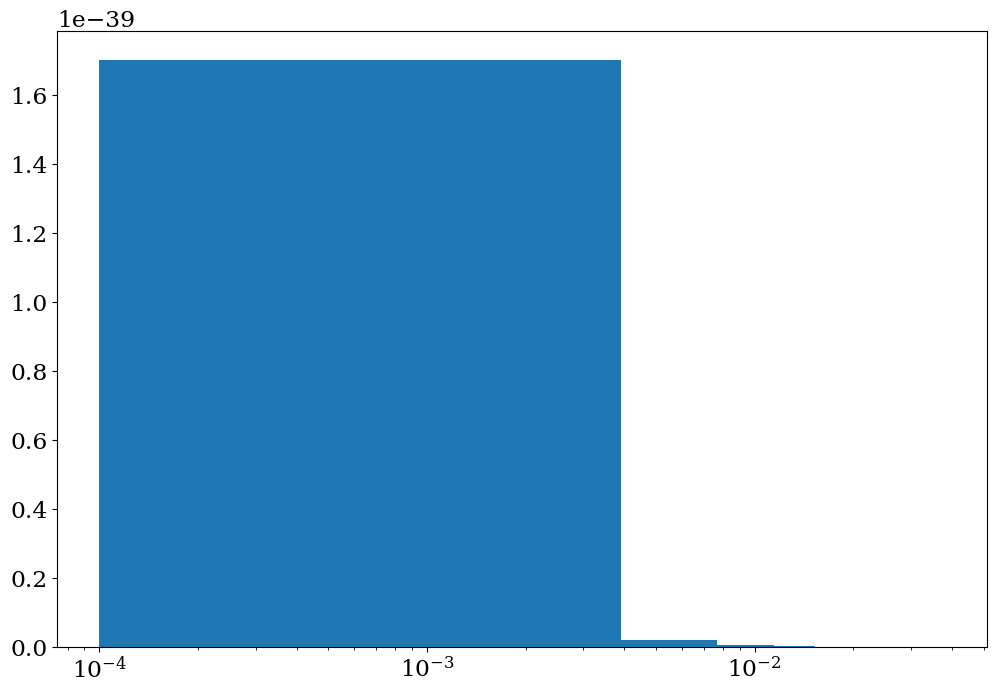

In [20]:
plt.hist(dwdthiele['f'], weights=dwdthiele['h']**2)
plt.xscale('log')